# Logistic Regression

Logistic Regression is a classification algorithm used to predict discrete (categorical) outcomes based on a set of independent variables. It is most commonly used for binary classification problems, where the outcome falls into one of two categories (e.g. Yes/No, Churn/No Churn).

### Applications of Logistic Regression

* Business & Customer Analytics

Customer churn prediction — will a customer leave or stay? 

Purchase prediction — will a customer buy a product or not?

Credit scoring — will a loan applicant default or repay?

* Healthcare & 

Disease diagnosis — does a patient have a condition or not, based on symptoms/test results? (e.g. malignant vs benign tumor)

Treatment outcome prediction — will a patient respond to a treatment?

* Marketing

Email spam detection — is this email spam or not spam?

Click-through prediction — will a user click on an ad or not?

* Finance

Fraud detection — is a transaction fraudulent or legitimate?

Loan approval — should a loan application be approved or rejected?

* HR & Recruitment

Employee attrition prediction — will an employee quit or stay?

Hiring decisions — will a candidate be a good fit or not, based on screening data?

* Social Sciences

Election outcome prediction — will a candidate win or lose in a specific district?

Survey response prediction — will someone respond "yes" or "no" to a question, based on demographic factors?

# Logistic Regression: Customer Churn Prediction

In [5]:
# Importing necessary libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Loading the dataset
Churn_df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
Churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
Churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# Check dataset size and full list of column names
print(Churn_df.shape)          # (rows, columns)
print(Churn_df.columns.tolist())   # list of every column name

(7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [14]:
# Check for missing values
print(Churn_df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [15]:
# Check data types
print(Churn_df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


Note: `TotalCharges` should be numeric (it represents a dollar amount), but it's currently stored as `object` (text). This happens because some rows contain blank/space values instead of numbers, which forces pandas to treat the whole column as text.

In [16]:
# Convert TotalCharges to numeric, forcing bad values to NaN
Churn_df['TotalCharges'] = pd.to_numeric(Churn_df['TotalCharges'], errors='coerce')

# Check how many values became missing
print(Churn_df['TotalCharges'].isnull().sum())

11


In [17]:
# Remove rows where TotalCharges is missing
Churn_df = Churn_df.dropna(subset=['TotalCharges'])

print(Churn_df.shape) #to recheck the shape of the dataset after removing missing values

(7032, 21)


In [18]:
# Checking for missing values again after dropping rows with NaN in TotalCharges
print(Churn_df.isnull().sum())



customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [19]:
# Checking data types again after conversion
print(Churn_df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


### Visualization

In [23]:
# Convert Churn (text: Yes/No) into numbers (1/0) so we can calculate correlation 1 = churned, 0 = did not churn
churn_numeric = Churn_df['Churn'].map({'Yes': 1, 'No': 0})

# Check how strongly each numeric column relates to churn
# Positive number = feature tends to go UP when churn happens, Negative number = feature tends to go DOWN when churn happens
print(Churn_df[['tenure', 'MonthlyCharges', 'TotalCharges']].corrwith(churn_numeric))

tenure           -0.354049
MonthlyCharges    0.192858
TotalCharges     -0.199484
dtype: float64


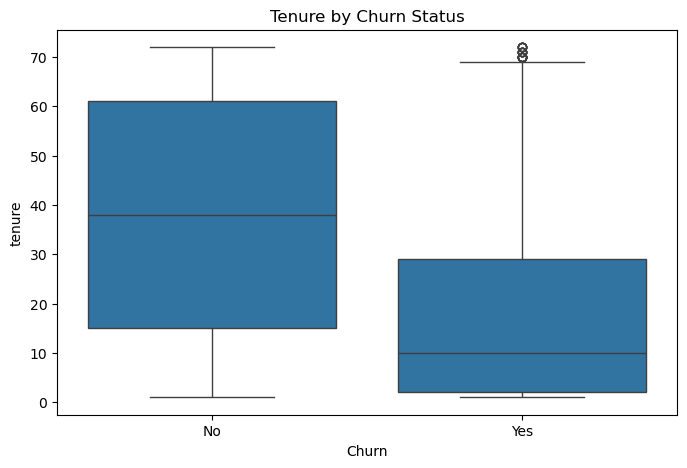

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the plot size
plt.figure(figsize=(8,5))

# Boxplot: compares the distribution of tenure between customers who churned vs stayed
# x = the two groups (Yes/No churn), y = the numeric value being compared (tenure)
sns.boxplot(x='Churn', y='tenure', data=Churn_df)

plt.title('Tenure by Churn Status')
plt.show()

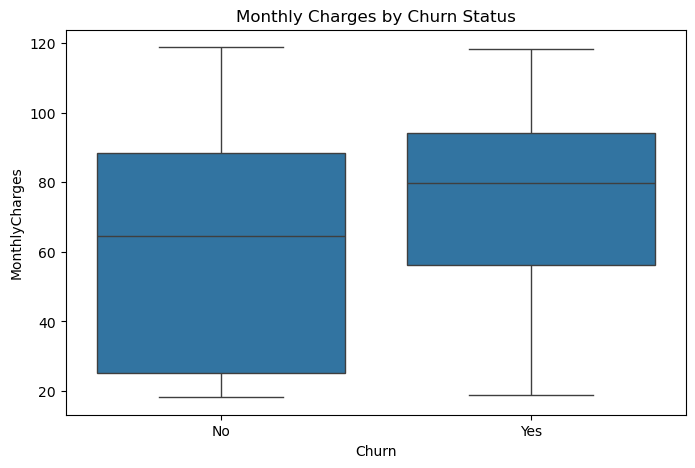

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=Churn_df)
plt.title('Monthly Charges by Churn Status')
plt.show()

In [27]:
# X = features (tenure, MonthlyCharges), y = target (Churn: Yes/No)
X = Churn_df[['tenure']].values
y = Churn_df['Churn'].values

print(X.shape, y.shape)

(7032, 1) (7032,)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)